# Módulo 1 · Optimización — Problema de transporte con capacidad limitada

Exploración de la red logística sintética (5 almacenes → 20 puntos de demanda) y de la solución óptima obtenida con PuLP/CBC.

**Modelo:** minimizar $\sum_{i,j} c_{ij} x_{ij}$ sujeto a capacidad por almacén y satisfacción total de demanda.

In [1]:
import sys; sys.path.append("..")
from src.utils import set_seeds, generate_network
from src.optimization import solve_transport, sensitivity_analysis, plot_solution
set_seeds()
net = generate_network()
net["warehouses"]

,warehouse_id,capacity,x,y
0,W1,1045,71.916484,45.110275
1,W2,1740,78.687834,65.789442
2,W3,514,17.534188,88.049788
3,W4,1845,70.891176,72.885144
4,W5,1314,20.249091,46.030875


In [2]:
net["demand_points"].describe()

,demand,x,y
count,20.000000,20.000000,20.000000
mean,177.050000,54.525490,49.461175
std,74.208437,24.054406,31.227800
min,77.000000,12.992151,4.380377
25%,117.750000,38.330829,21.908872
50%,196.500000,51.207030,42.308232
75%,232.250000,74.809355,80.926367
max,294.000000,97.069802,96.750973


## 1 · Solución óptima del caso base

Resolvemos el LP con CBC. La tabla de **utilización** por almacén incluye `shadow_price`: el dual de cada restricción de capacidad, es decir el cambio marginal de costo por una unidad extra de capacidad.

In [3]:
# Solución base
res = solve_transport()
print(f"Status: {res.status} | Costo total: ${res.total_cost:,.2f}")
res.utilization

Status: Optimal | Costo total: $14,791.35


,capacity,used,utilization_pct,shadow_price
W1,1045,1045.0,100.0,-0.29
W2,1740,642.0,36.9,0.00
W3,514,85.0,16.5,0.00
W4,1845,544.0,29.5,0.00
W5,1314,1225.0,93.2,0.00


**Lectura — precio sombra:** solo **W1** opera al 100 % y tiene dual ≠ 0 (`-0.29`); el resto tiene capacidad de sobra, así que su precio sombra es 0 (holgura complementaria). Conclusión accionable: **W1 es el cuello de botella** — cada unidad extra de su capacidad ahorraría ≈ \$0.29, por lo que es el primer almacén a ampliar.

In [4]:
# Top-10 flujos por costo
res.flows.sort_values("cost", ascending=False).head(10)

,warehouse_id,point_id,units,cost
5,W1,D20,294.0,1417.08
2,W1,D13,232.0,1296.88
14,W5,D3,189.0,1024.38
12,W4,D11,215.0,1006.20
19,W5,D15,242.0,994.62
4,W1,D19,243.0,984.15
18,W5,D14,285.0,943.35
8,W2,D7,218.0,930.86
7,W2,D6,217.0,928.76
17,W5,D12,233.0,859.77


In [5]:
# Análisis de sensibilidad: ¿qué pasa si la demanda crece hasta +20%?
sens = sensitivity_analysis()
sens

,demand_multiplier,status,total_cost,max_utilization_pct
0,1.00,Optimal,14791.35,100.0
1,1.05,Optimal,15548.27,100.0
2,1.10,Optimal,16313.21,100.0
3,1.15,Optimal,17097.88,100.0
4,1.20,Optimal,17890.01,100.0


**Lectura:** el costo crece de forma aproximadamente lineal con la demanda (~+4-5% de costo por cada +5% de demanda) porque la red aún tiene holgura agregada de capacidad. El cuello de botella aparece en los almacenes que operan al 100% de utilización: a +20% el sistema sigue siendo factible, pero el costo marginal aumenta al desviarse flujo hacia rutas más caras.

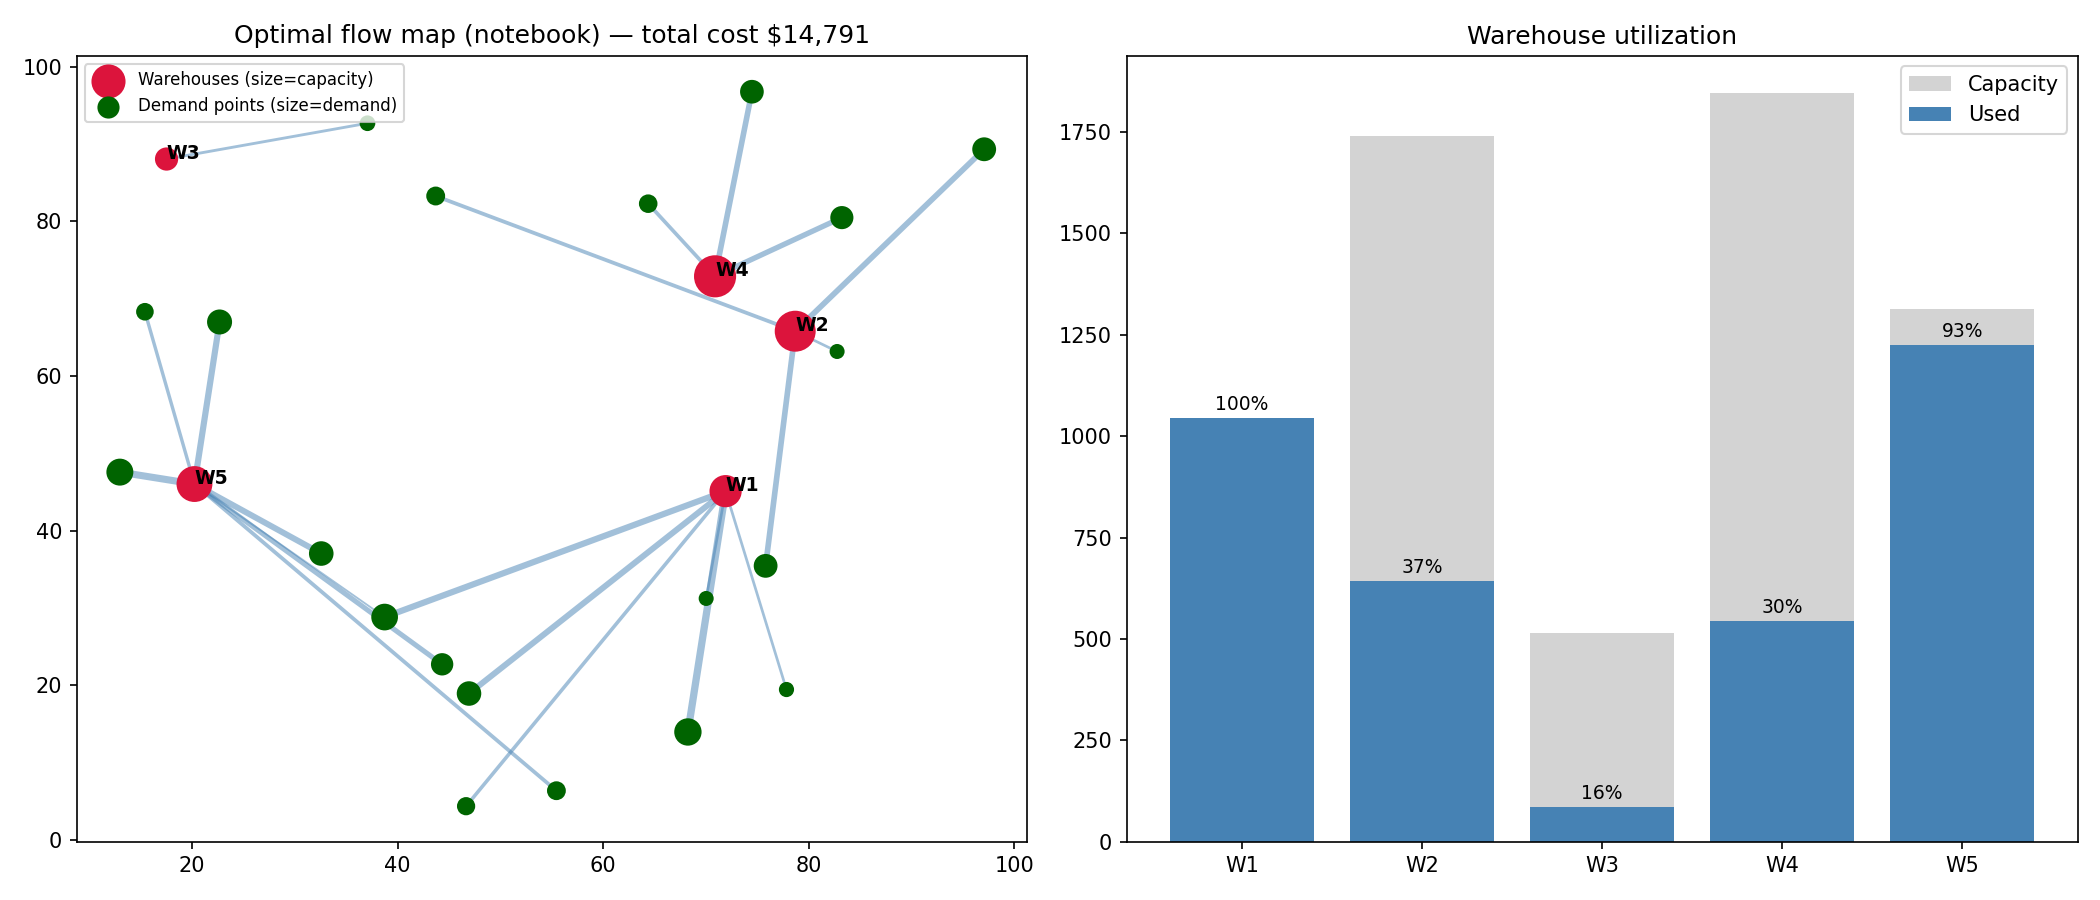

In [6]:
plot_solution(res, suffix="notebook")
from IPython.display import Image
Image("../figures/optimization_notebook.png")

*Mapa de flujos óptimo: el grosor de cada arista es proporcional a las unidades enviadas; el tamaño de cada nodo, a la capacidad (almacenes) o a la demanda (puntos).*